#### Contents:
 1. Loading up Mass balance CSV's
 2. Computing rolling means of MB components
 3. Plots of MB time series (Normal + rolling mean)
 4. Regional classification of glaciers (North & South)
 5. Computing cumulative MB and plotting it

In [ ]:
import glob
import os 

folder_path = r"C:\Users\danis\Desktop\Danish\NVE\glaciers\Mass Balance"
csv_files= glob.glob(os.path.join(folder_path, '*.csv'))
for f in csv_files:
    print (os.path.basename(f))

Alfotbreen.csv
Austdalsbreen.csv
Engabreen.csv
Grafjellsbrea.csv
Grasubreen.csv
Hansebreen.csv
Hellstugubreen.csv
Langfjordjokelen.csv
Nigardsbreen.csv
Rembesdalskåka.csv
Storbreen.csv


In [2]:
import pandas as pd
sample_file= csv_files[0]
df_sample= pd.read_csv(sample_file, encoding='cp1252', sep=';')
print(df_sample.head())
print(df_sample.columns)

   Year  GlacierId DateMinPrevYear     DateMax     DateMin ElaPrefix     Ela  \
0  1963       2078      10.11.1962  23.05.1963  22.10.1963       NaN  1270.0   
1  1964       2078      22.10.1963  28.04.1964  04.11.1964       NaN  1165.0   
2  1965       2078      04.11.1964  28.05.1965  22.10.1965       NaN  1105.0   
3  1966       2078      22.10.1965  09.04.1966  18.11.1966         >  1380.0   
4  1967       2078      18.11.1966  29.04.1967  10.12.1967       NaN  1020.0   

    Aar  ElMin  ElMax   Area    Bw     Bs     Ba  Bcalv DataOwner  \
0  37.0    869   1380  4,486  2,52  -3,21   -0,7    NaN       NVE   
1  69.0    869   1380  4,486  2,66  -2,38   0,28    NaN       NVE   
2  83.0    869   1380  4,486  3,75  -3,07   0,68    NaN       NVE   
3   0.0    869   1380  4,486   2,4  -3,93  -1,53    NaN       NVE   
4  94.0    869   1380  4,486  4,43  -3,12    1,3    NaN       NVE   

                                MassBalanceReference  Flag ReanalysisStatus  
0  Kjøllmoen, B. 2016. Rea

In [ ]:
dfs= []
for file in csv_files:
    df= pd.read_csv(file, encoding='cp1252', sep=';', decimal=',')
    # parse_dates=['Date'], dayfirst=True
    
    glacier_name= os.path.splitext(os.path.basename(file))[0]
    df['Glacier']= glacier_name
    df= df[['Year', 'GlacierId', 'Glacier', 'Bs', 'Bw', 'Ba']]
    dfs.append(df)

glacier_data_df= pd.concat(dfs, ignore_index=True)


In [4]:
print(glacier_data_df.head())
print(glacier_data_df.columns)
print(glacier_data_df['Glacier'].unique())

   Year  GlacierId     Glacier    Bs    Bw    Ba
0  1963       2078  Alfotbreen -3.21  2.52 -0.70
1  1964       2078  Alfotbreen -2.38  2.66  0.28
2  1965       2078  Alfotbreen -3.07  3.75  0.68
3  1966       2078  Alfotbreen -3.93  2.40 -1.53
4  1967       2078  Alfotbreen -3.12  4.43  1.30
Index(['Year', 'GlacierId', 'Glacier', 'Bs', 'Bw', 'Ba'], dtype='object')
['Alfotbreen' 'Austdalsbreen' 'Engabreen' 'Grafjellsbrea' 'Grasubreen'
 'Hansebreen' 'Hellstugubreen' 'Langfjordjokelen' 'Nigardsbreen'
 'Rembesdalskåka' 'Storbreen']


In [5]:
north_glaciers= ['Engabreen', 'Langfjordjokelen']
region_list=[]

for glacier in glacier_data_df['Glacier']:
    if glacier in north_glaciers:
        region_list.append('North')
    else:
        region_list.append('South')
glacier_data_df['Region']= region_list
print(glacier_data_df.head())

   Year  GlacierId     Glacier    Bs    Bw    Ba Region
0  1963       2078  Alfotbreen -3.21  2.52 -0.70  South
1  1964       2078  Alfotbreen -2.38  2.66  0.28  South
2  1965       2078  Alfotbreen -3.07  3.75  0.68  South
3  1966       2078  Alfotbreen -3.93  2.40 -1.53  South
4  1967       2078  Alfotbreen -3.12  4.43  1.30  South


In [6]:
glacier_data_df['Cumulative_Ba']= glacier_data_df.groupby('Glacier')['Ba'].cumsum()
glacier_data_df['Rolling_Bs']= glacier_data_df.groupby('Glacier')['Bs'].transform(lambda x: x.rolling(window=5, center=True).mean())
glacier_data_df['Rolling_Bw']= glacier_data_df.groupby('Glacier')['Bw'].transform(lambda x: x.rolling(window=5, center=True).mean())
print(glacier_data_df.head())

   Year  GlacierId     Glacier    Bs    Bw    Ba Region  Cumulative_Ba  \
0  1963       2078  Alfotbreen -3.21  2.52 -0.70  South          -0.70   
1  1964       2078  Alfotbreen -2.38  2.66  0.28  South          -0.42   
2  1965       2078  Alfotbreen -3.07  3.75  0.68  South           0.26   
3  1966       2078  Alfotbreen -3.93  2.40 -1.53  South          -1.27   
4  1967       2078  Alfotbreen -3.12  4.43  1.30  South           0.03   

   Rolling_Bs  Rolling_Bw  
0         NaN         NaN  
1         NaN         NaN  
2      -3.142       3.152  
3      -3.228       3.578  
4      -3.736       3.562  


## Loading in glacier data pickle file 

In [1]:
import pandas as pd 

glacier_data_df= pd.read_pickle(r"C:\Users\danis\Desktop\Danish\Scripts_Python\glacier_data.pkl")
print(glacier_data_df.head())

   Year  GlacierId     Glacier    Bs    Bw    Ba Region  Cumulative_Ba  \
0  1963       2078  Alfotbreen -3.21  2.52 -0.70  South          -0.70   
1  1964       2078  Alfotbreen -2.38  2.66  0.28  South          -0.42   
2  1965       2078  Alfotbreen -3.07  3.75  0.68  South           0.26   
3  1966       2078  Alfotbreen -3.93  2.40 -1.53  South          -1.27   
4  1967       2078  Alfotbreen -3.12  4.43  1.30  South           0.03   

   Rolling_Bs  Rolling_Bw GlacierShort  
0         NaN         NaN          Alf  
1         NaN         NaN          Alf  
2      -3.142       3.152          Alf  
3      -3.228       3.578          Alf  
4      -3.736       3.562          Alf  


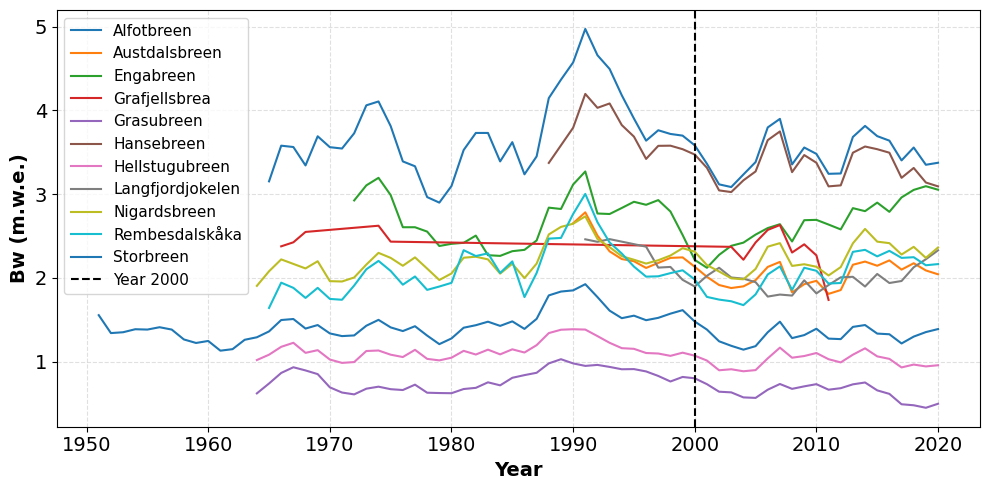

In [ ]:
#Individual Plots:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(10,5))
gridline_color = "#d3d3d3"

for glacier, group in glacier_data_df.groupby('Glacier'):
    plt.plot(group['Year'], group['Rolling_Bw'], label=glacier)

#plt.title('Bw Time Series', size=14)

plt.xlabel('Year', size=14, fontweight='bold')
plt.ylabel('Bw (m.w.e.)', size=14, fontweight='bold')
plt.xticks(size=14)
plt.yticks(size=14)
plt.axvline(x=2000, color='black', linestyle='--', label='Year 2000')

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', color=gridline_color, alpha=0.7)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\01- Mass Balance\Bw_Time_Series.png", dpi=800, bbox_inches='tight')
plt.show()
           

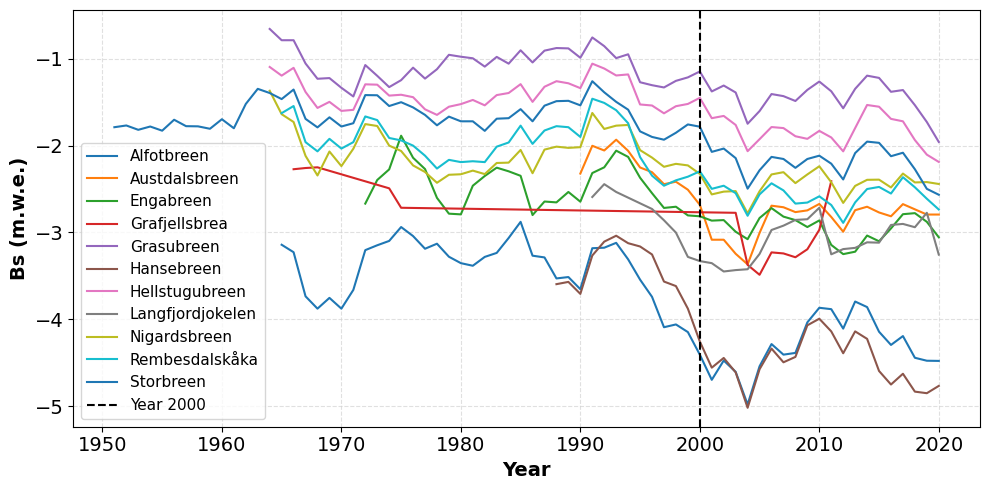

In [ ]:
plt.figure(figsize=(10,5))
gridline_color = "#d3d3d3"

for glacier, group in glacier_data_df.groupby('Glacier'):
    plt.plot(group['Year'], group['Rolling_Bs'], label=glacier)

#plt.title('Bs Time Series', size=14)
plt.xlabel('Year', size=14, fontweight='bold')
plt.ylabel('Bs (m.w.e.)', size=14, fontweight='bold')
plt.xticks(size=14)
plt.yticks(size=14)
plt.axvline(x=2000, color='black', linestyle='--', label='Year 2000')

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', color=gridline_color, alpha=0.7)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\01- Mass Balance\Bs_Time_Series.png", dpi=800, bbox_inches='tight')
plt.show()
           

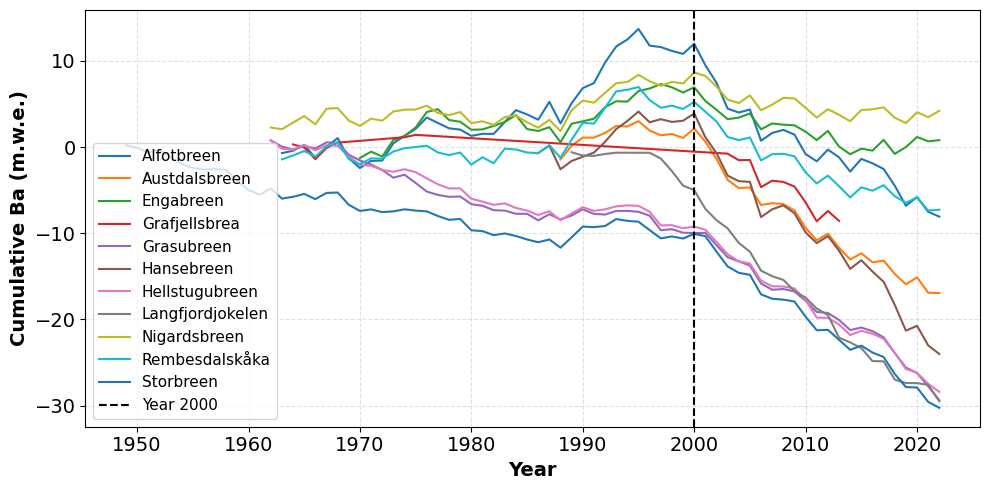

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(10,5))
gridline_color = "#d3d3d3"

for glacier, group in glacier_data_df.groupby('Glacier'):
    plt.plot(group['Year'], group['Cumulative_Ba'], label=glacier) #alpha=0.6)

#plt.title('Cumulative Ba Time Series', size=14)
plt.xlabel('Year', size=14, fontweight='bold')
plt.ylabel('Cumulative Ba (m.w.e.)', size=14, fontweight='bold')
plt.xticks(size=14)
plt.yticks(size=14)
plt.axvline(x=2000, color='black', linestyle='--', label='Year 2000')

plt.legend(fontsize=11)
plt.grid(True, linestyle='--', color=gridline_color, alpha=0.7)
plt.tight_layout()
#plt.savefig(r"C:\Users\danis\Desktop\Danish\Py-Plots\01- Mass Balance\Cumulative_Ba_Time_Series.png", dpi=800, bbox_inches='tight')
plt.show()


In [13]:
os.getcwd()
print(glacier_data_df.head())
glacier_data_df.to_pickle('glacier_data.pkl')

   Year  GlacierId     Glacier    Bs    Bw    Ba Region  Cumulative_Ba  \
0  1963       2078  Alfotbreen -3.21  2.52 -0.70  South          -0.70   
1  1964       2078  Alfotbreen -2.38  2.66  0.28  South          -0.42   
2  1965       2078  Alfotbreen -3.07  3.75  0.68  South           0.26   
3  1966       2078  Alfotbreen -3.93  2.40 -1.53  South          -1.27   
4  1967       2078  Alfotbreen -3.12  4.43  1.30  South           0.03   

   Rolling_Bs  Rolling_Bw  
0         NaN         NaN  
1         NaN         NaN  
2      -3.142       3.152  
3      -3.228       3.578  
4      -3.736       3.562  
